# Facial Expression Classification — FER-2013
## Model 1: ResNet50V2 Transfer Learning with Image Augmentation

In [1]:
# Install kaggle if not already installed
!pip install kaggle -q

In [2]:
# ── Core imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Kaggle authentication ──────────────────────────────────────
# Upload your kaggle.json first via Files panel on the left
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle API key configured.')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured.


In [4]:
# ── Download and unzip FER-2013 dataset ───────────────────────
!kaggle datasets download -d msambare/fer2013 --force
!unzip -o fer2013.zip -d fer2013_data
print('Dataset ready.')

Streaming output truncated to the last 5000 lines.
  inflating: fer2013_data/train/sad/Training_65267116.jpg  
  inflating: fer2013_data/train/sad/Training_65275626.jpg  
  inflating: fer2013_data/train/sad/Training_6529266.jpg  
  inflating: fer2013_data/train/sad/Training_65329617.jpg  
  inflating: fer2013_data/train/sad/Training_65338712.jpg  
  inflating: fer2013_data/train/sad/Training_65338797.jpg  
  inflating: fer2013_data/train/sad/Training_65387162.jpg  
  inflating: fer2013_data/train/sad/Training_65404494.jpg  
  inflating: fer2013_data/train/sad/Training_65426218.jpg  
  inflating: fer2013_data/train/sad/Training_65430136.jpg  
  inflating: fer2013_data/train/sad/Training_65437377.jpg  
  inflating: fer2013_data/train/sad/Training_6545735.jpg  
  inflating: fer2013_data/train/sad/Training_65463385.jpg  
  inflating: fer2013_data/train/sad/Training_65473985.jpg  
  inflating: fer2013_data/train/sad/Training_65502829.jpg  
  inflating: fer2013_data/train/sad/Training_655053

In [5]:
# ── Directory paths ────────────────────────────────────────────
train_dir = 'fer2013_data/train'
test_dir  = 'fer2013_data/test'

# Check class folders exist
print('Train classes:', os.listdir(train_dir))
print('Test  classes:', os.listdir(test_dir))

Train classes: ['disgust', 'sad', 'fear', 'happy', 'angry', 'surprise', 'neutral']
Test  classes: ['disgust', 'sad', 'fear', 'happy', 'angry', 'surprise', 'neutral']


## Image Transformations — Rationale

FER-2013 contains 48x48 grayscale face images. The following augmentations were chosen carefully:

| Transformation | Reason |
|---|---|
| **Horizontal flip** | Faces look the same mirrored — valid augmentation |
| **Rotation (±15°)** | Accounts for natural head tilts in real photos |
| **Zoom (±10%)** | Faces appear at different distances from camera |
| **Width/Height shift (±10%)** | Face may not be perfectly centred |
| **Brightness adjustment** | Different lighting conditions in real environments |
| **Rescale 1/255** | Normalises pixel values to [0, 1] range |

**Transformations deliberately avoided:**
- Vertical flip — upside-down faces are not realistic
- Heavy shear/distortion — would destroy facial expression features
- Channel shift — not applicable for grayscale images

**Note:** ResNet50V2 requires RGB input (3 channels) and minimum 32x32 size.
We resize images to 224x224 and convert grayscale to RGB by repeating channels.

In [6]:
# ── Configuration ──────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 7
EPOCHS_FROZEN   = 15    # Train only the top layers first
EPOCHS_UNFROZEN = 25    # Fine-tune the whole network

In [7]:
# ── Image Augmentation for Training Data ──────────────────────
# These transformations are ONLY applied to training data
# to artificially increase dataset diversity and reduce overfitting

train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalise pixels to [0, 1]
    validation_split=0.2,       # 80% train, 20% validation

    # ── Geometric transformations ──
    horizontal_flip=True,       # Mirror faces horizontally
    rotation_range=8,          # Rotate up to 15 degrees either way
    zoom_range=0.10,            # Zoom in/out by up to 10%
    width_shift_range=0.05,     # Shift left/right by up to 10%
    height_shift_range=0.05,    # Shift up/down by up to 10%

    fill_mode='nearest'          # Fill empty pixels after rotation/shift
)

# Validation and test data: ONLY rescale, NO augmentation
# (we want a fair, unmodified evaluation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# ── Test Generator ─────────
# ONLY rescale
test_datagen = ImageDataGenerator(
    rescale=1./255
)

print('Data generators configured.')

Data generators configured.


In [8]:
# ── Data Loaders ───────────────────────────────────────────────
# ResNet50V2 requires colour_mode='rgb' (3 channels)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',           # Convert grayscale to 3-channel RGB
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                # Keep order for confusion matrix
)

class_names = list(train_data.class_indices.keys())
print('Classes:', class_names)
print('Training samples:  ', train_data.samples)
print('Validation samples:', val_data.samples)
print('Test samples:      ', test_data.samples)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples:   22968
Validation samples: 5741
Test samples:       7178


In [9]:
# Get class indices from training generator
class_indices = train_data.classes

# Compute balanced weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_indices),
    y=class_indices
)

# Convert to dictionary format required by Keras
class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: np.float64(1.0266404434114071), 1: np.float64(9.401555464592715), 2: np.float64(1.0009587727708533), 3: np.float64(0.5684585684585685), 4: np.float64(0.826068191627104), 5: np.float64(0.8491570541259982), 6: np.float64(1.2933160650937552)}


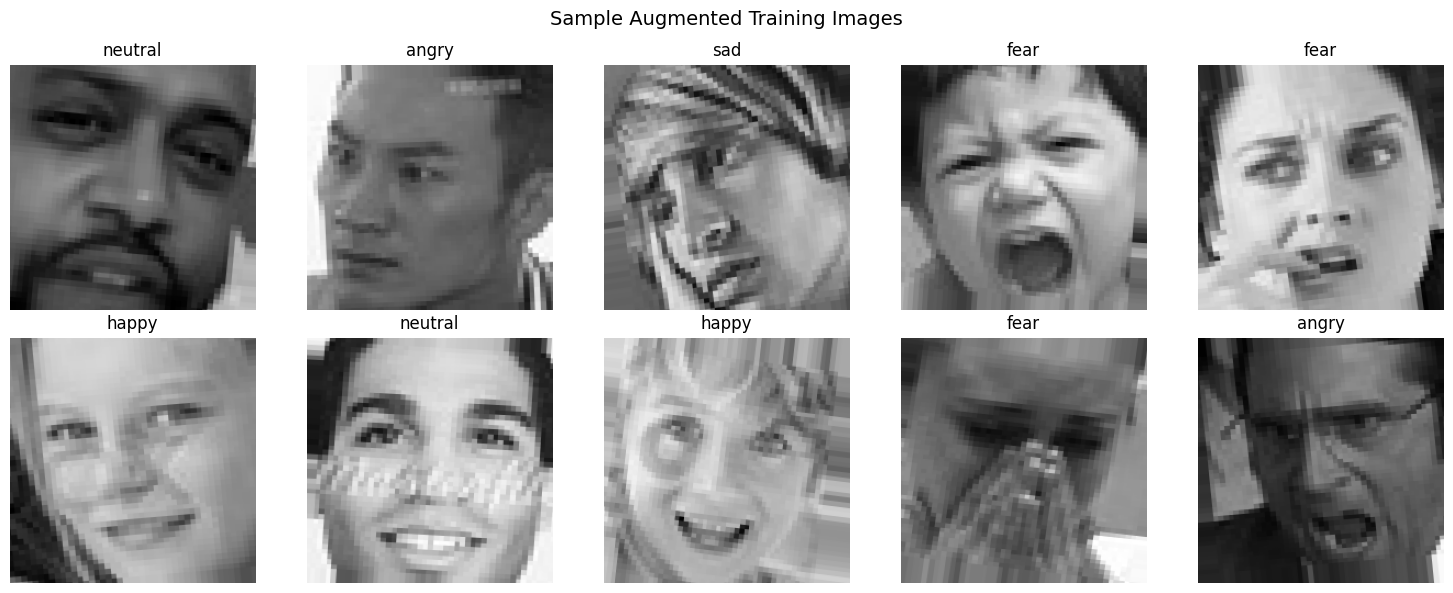

In [10]:
# ── Visualise augmented training samples ──────────────────────
# This confirms augmentation is working correctly

sample_images, sample_labels = next(train_data)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

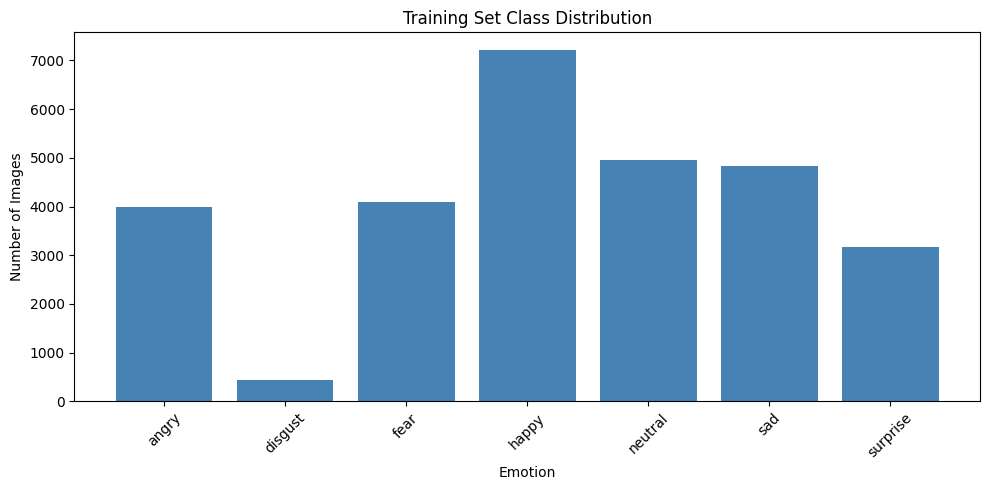

Class distribution: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


In [11]:
# ── Visualise class distribution ──────────────────────────────
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Training Set Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Class distribution:', class_counts)

## ResNet50V2 Transfer Learning — Architecture

**Why transfer learning?**
ResNet50V2 was pre-trained on ImageNet (1.2 million images, 1000 classes).
Its early layers already detect edges, textures, and shapes — features also
useful for facial expression recognition. We fine-tune it for our 7-class task.

**Two-stage training strategy:**
1. **Stage 1 — Frozen base:** Train only the new classification head. The ResNet weights stay fixed. This prevents the pre-trained features from being destroyed early on.
2. **Stage 2 — Fine-tuning:** Unfreeze the top layers of ResNet and train the whole network at a very low learning rate to gently adapt the features to facial expressions.

In [12]:
# ── Build ResNet50V2 Transfer Learning Model ───────────────────

def build_resnet_model(input_shape=(224, 224, 3), num_classes=7):
    """
    Builds a ResNet50V2 transfer learning model.
    The base model is loaded with ImageNet weights and frozen initially.
    A custom classification head is added on top.
    """
    # Load pre-trained ResNet50V2 without the top classification layer
    base_model = ResNet50V2(
        weights='imagenet',       # Use ImageNet pre-trained weights
        include_top=False,        # Remove the original 1000-class head
        input_shape=input_shape
    )

    # Freeze all base model layers (Stage 1)
    base_model.trainable = False
    print(f'Base model layers: {len(base_model.layers)}')
    print(f'Trainable layers (frozen): {len([l for l in base_model.layers if l.trainable])}')

    # Build the full model
    inputs = tf.keras.Input(shape=input_shape)

    # Pass through ResNet50V2 base
    x = base_model(inputs, training=False)  # training=False keeps BatchNorm frozen

    # Global Average Pooling — reduces spatial dimensions
    x = layers.GlobalAveragePooling2D()(x)

    # Classification head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)              # Dropout to reduce overfitting
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer — 7 emotion classes
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='ResNet50V2_FER')
    return model, base_model


resnet_model, base_model = build_resnet_model(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

resnet_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base model layers: 190
Trainable layers (frozen): 0


Model: "ResNet50V2_FER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,143 (92.02 MB)

 Trainable params: 558,343 (2.13 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [13]:
# ── Stage 1: Train classification head only (base frozen) ─────

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to prevent overfitting and reduce learning rate on plateau
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Stage 1: Training classification head (base frozen)...')
history_stage1 = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_stage1,
    class_weight=class_weights,
    verbose=1
)

print('Stage 1 complete.')

Stage 1: Training classification head (base frozen)...
Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 329s 437ms/step - accuracy: 0.3130 - loss: 1.7697 - val_accuracy: 0.3980 - val_loss: 1.5804 - learning_rate: 0.0010
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 293s 408ms/step - accuracy: 0.3689 - loss: 1.6219 - val_accuracy: 0.4330 - val_loss: 1.5204 - learning_rate: 0.0010
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 292s 407ms/step - accuracy: 0.3950 - loss: 1.5564 - val_accuracy: 0.4510 - val_loss: 1.4580 - learning_rate: 0.0010
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 294s 410ms/step - accuracy: 0.4058 - loss: 1.5287 - val_accuracy: 0.4175 - val_loss: 1.5327 - learning_rate: 0.0010
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 298s 415ms/step - accuracy: 0.4220 - loss: 1.4917 - val_accuracy: 0.4471 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 299s 417ms/step - accuracy: 0.4303 - loss: 1.4620 - val_accuracy: 0.4750 - val_loss: 1.4207 - learning_rate: 0.0010
Epoch 7/1

In [15]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Define checkpoint directory
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory created at: {CHECKPOINT_DIR}')

Mounted at /content/drive
Checkpoint directory created at: /content/drive/MyDrive/checkpoints


In [16]:
# Save model after Stage 1
stage1_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    'resnet50v2_stage1.weights.h5'
)

resnet_model.save_weights(stage1_checkpoint_path)

print(f'Stage 1 weights saved to: {stage1_checkpoint_path}')

Stage 1 weights saved to: /content/drive/MyDrive/checkpoints/resnet50v2_stage1.weights.h5


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(
        CHECKPOINT_DIR,
        'resnet50v2_stage2_best.weights.h5'
    ),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)
# ── Stage 2: Fine-tune — unfreeze top layers of ResNet ─────────

# Unfreeze the top 30 layers of the base model
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False   # Keep lower layers frozen

trainable_count = len([l for l in base_model.layers if l.trainable])
print(f'Fine-tuning top {trainable_count} layers of ResNet50V2')

# Recompile with a much lower learning rate for fine-tuning
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # Very low LR to avoid destroying weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    checkpoint_callback
]

print('Stage 2: Fine-tuning top layers...')
history_stage2 = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_UNFROZEN,
    callbacks=callbacks_stage2,
    verbose=1,
    class_weight=class_weights
)

print('Stage 2 complete.')

Fine-tuning top 30 layers of ResNet50V2
Stage 2: Fine-tuning top layers...
Epoch 1/25
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.3764 - loss: 1.9750
Epoch 1: val_loss improved from None to 1.37059, saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5
718/718 ━━━━━━━━━━━━━━━━━━━━ 341s 450ms/step - accuracy: 0.3996 - loss: 1.7107 - val_accuracy: 0.4769 - val_loss: 1.3706 - learning_rate: 1.0000e-05
Epoch 2/25
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.4530 - loss: 1.4548
Epoch 2: val_loss improved from 1.37059 to 1.33139, saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5
718/718 ━━━━━━━━━━━━━━━━━━━━ 366s 438ms/step - accuracy: 0.4637 - loss: 1.4107 - val_accuracy: 0.4929 - val_loss: 1.3314 

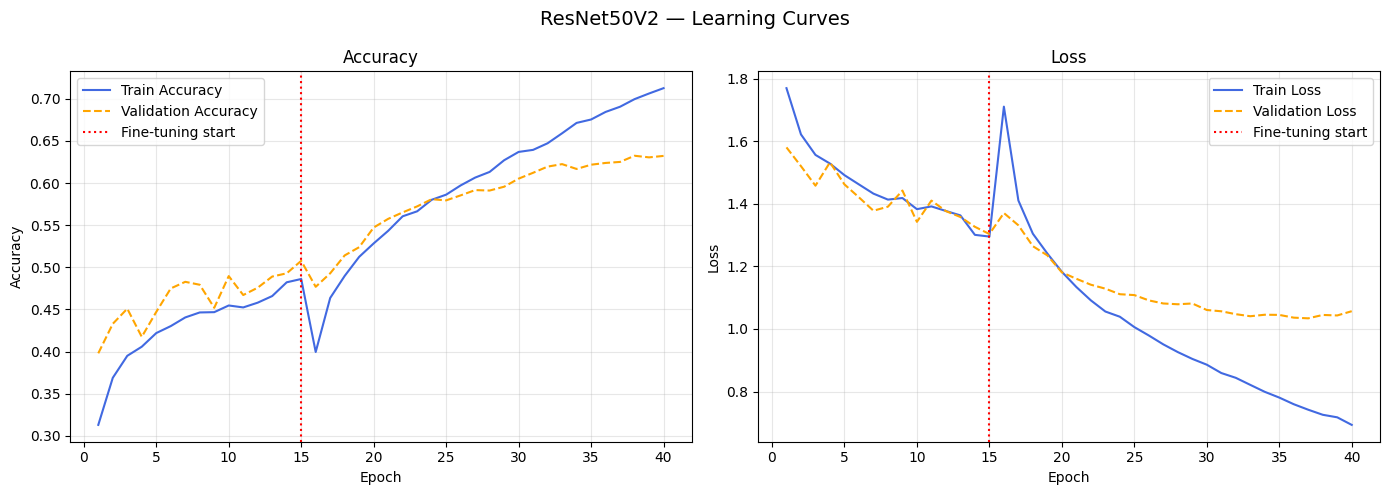

In [18]:
# ── Plot Learning Curves (both stages combined) ────────────────

def plot_learning_curves(history1, history2, title_prefix='ResNet50V2'):
    """
    Combines training history from both stages and plots
    accuracy and loss learning curves.
    """
    # Combine both stages
    acc     = history1.history['accuracy']     + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss    = history1.history['loss']         + history2.history['loss']
    val_loss= history1.history['val_loss']     + history2.history['val_loss']

    stage_boundary = len(history1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title_prefix} — Learning Curves', fontsize=14)

    # Accuracy plot
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linestyle='--')
    ax1.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss plot
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linestyle='--')
    ax2.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_stage1, history_stage2, 'ResNet50V2')

In [19]:
# ── Evaluate on Test Set ───────────────────────────────────────

print('Evaluating ResNet50V2 on test set...')
test_loss, test_acc = resnet_model.evaluate(test_data, verbose=1)
print(f'\nTest Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Evaluating ResNet50V2 on test set...
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.6371 - loss: 1.0222

Test Loss:     1.0222
Test Accuracy: 0.6371 (63.71%)


In [20]:
# ── Predictions and Classification Report ─────────────────────

# Reset test generator to ensure correct order
test_data.reset()

# Generate predictions
y_pred_probs   = resnet_model.predict(test_data, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = test_data.classes

print('\nClassification Report:')
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.53      0.58      0.55       958
     disgust       0.58      0.60      0.59       111
        fear       0.56      0.32      0.41      1024
       happy       0.85      0.84      0.84      1774
     neutral       0.56      0.66      0.60      1233
         sad       0.51      0.51      0.51      1247
    surprise       0.71      0.84      0.77       831

    accuracy                           0.64      7178
   macro avg       0.61      0.62      0.61      7178
weighted avg       0.64      0.64      0.63      7178



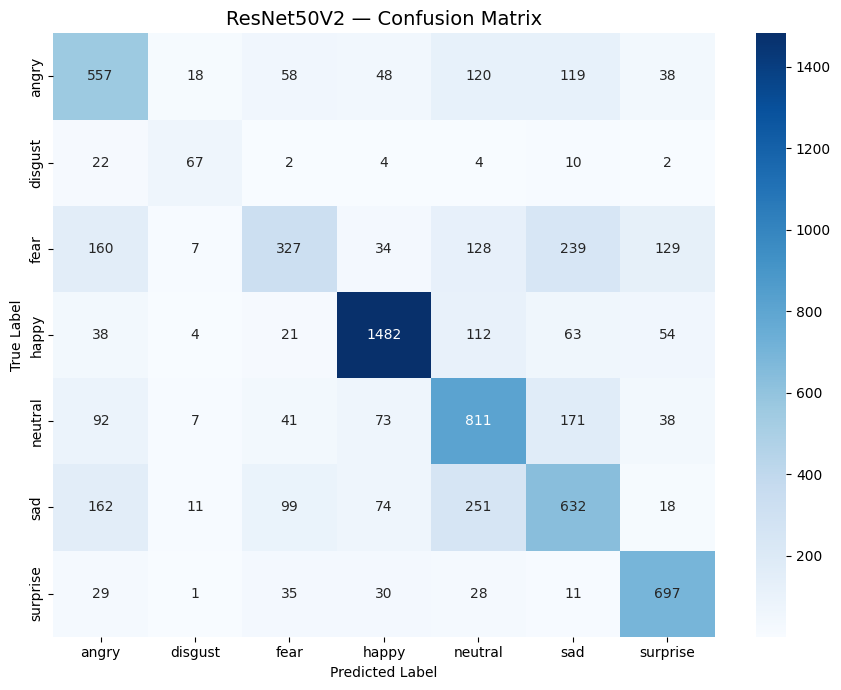

Confusion matrix displayed.


In [21]:
# ── Confusion Matrix ───────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ResNet50V2 — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('Confusion matrix displayed.')

In [22]:
# ── Save the model for reuse ───────────────────────────────────
resnet_model.save('resnet50v2_fer2013.h5')
print('Model saved as resnet50v2_fer2013.h5')

Model saved as resnet50v2_fer2013.h5


In [23]:
resnet_model.save('my_model.keras')